## 0 · Setup y carga del panel

In [1]:
import sys, warnings, pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mectesis.empirical.loaders import build_panel
from mectesis.empirical.transforms import log_diff, select_optimal_lags, apply_lags
from mectesis.empirical import diagnostics as diag
from mectesis.empirical import describe as desc
from mectesis.empirical.backtest import (
    compare_models, to_wide_table, predict_all_at_last_origin,
)
from mectesis.empirical.autoselect import (
    AutoARIMAModel, AutoETSModel, AutoThetaModel, AutoSARIMAXModel,
)
from mectesis.models.var_model import VARModel, VECMModel
from mectesis.models.chronos import ChronosModel
from mectesis.models.chronos_multivariate import ChronosMultivariateModel
from mectesis.models.chronos_covariate import ChronosCovariateModel

START, END = "2016-12-01", "2026-05-01"
INITIAL_WINDOW = 72
HORIZONS = [1, 3, 6, 12]

# Pipeline Chronos compartido entre las 3 variantes (univariada, multi, covariables)
chronos_pipeline = ChronosModel(device="cpu")

In [2]:
panel = build_panel(start=START, end=END)
print(f"Panel shape: {panel.shape}, rango {panel.index.min().date()} -> {panel.index.max().date()}")
print(panel.isna().sum())
panel.head()

Panel shape: (113, 6), rango 2016-12-01 -> 2026-04-01
ipc       0
tpm       0
badlar    0
tcm       0
m2        0
rem       0
dtype: int64


,ipc,tpm,badlar,tcm,m2,rem
fecha,,,,,,
2016-12-01,1.2,23.1,20.0,15.8296,22.2,19.6
2017-01-01,1.3,21.8,19.8,15.9065,28.6,19.7
2017-02-01,2.5,21.0,20.1,15.5983,30.7,19.5
2017-03-01,2.4,21.5,19.5,15.5237,31.9,18.4
2017-04-01,2.6,22.6,19.2,15.3600,31.9,17.5


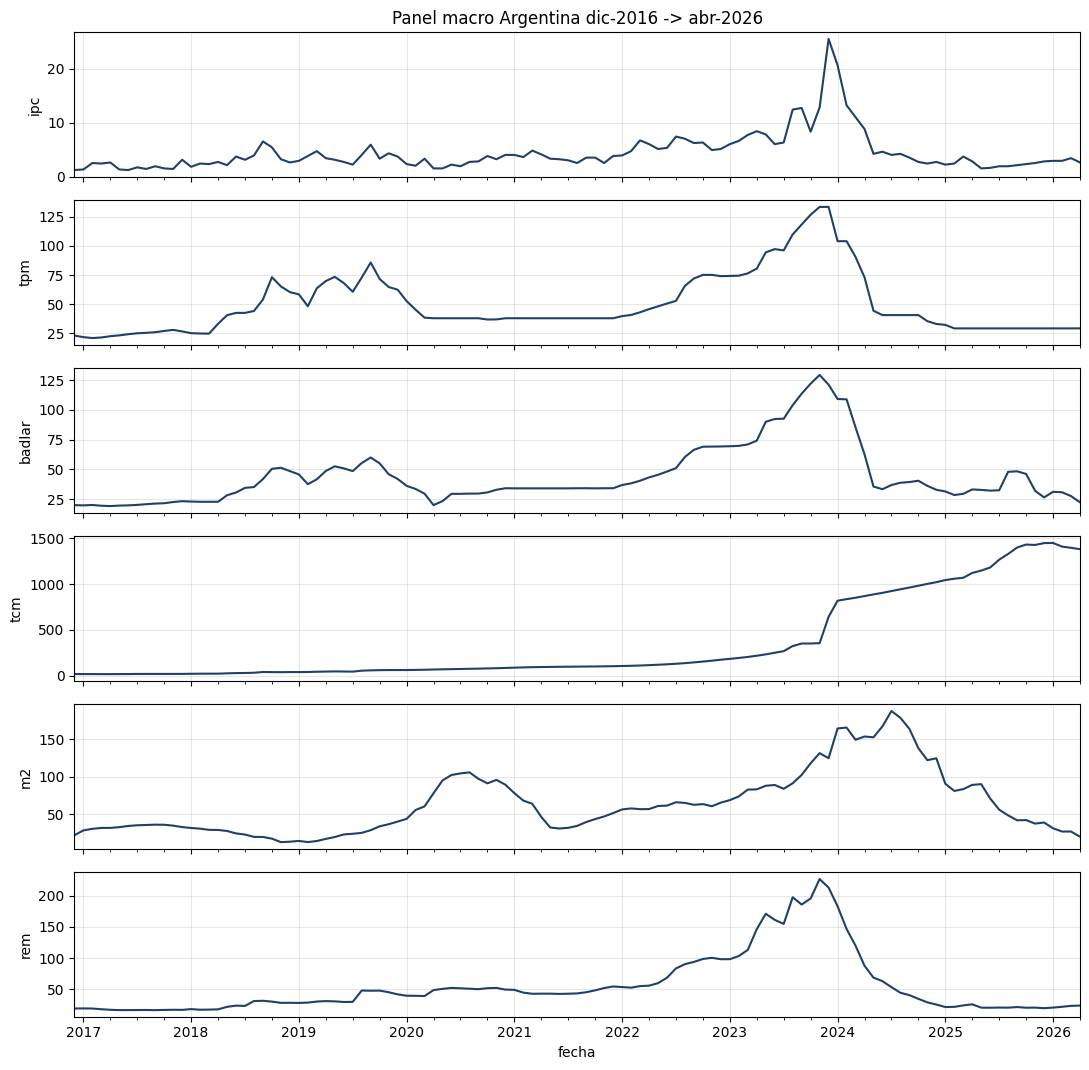

In [3]:
desc.plot_panel(panel, title="Panel macro Argentina dic-2016 -> abr-2026")
plt.show()

## 1 · Validación univariada (π mensual)

El IPC del panel ya es tasa de inflación mensual %. Modelos: AutoARIMA, AutoETS, AutoTheta, Chronos-2.

Cambios vs notebook base:
- Una sola figura ACF/PACF (Ljung-Box reportado solo como p-valor citado en celda de diagnóstico).
- Tabla compacta de diagnósticos (raíces unitarias, ARCH, normalidad) en lugar de bloques separados; sin Q-Q plot.

  n      start        end     mean      std  min  p25  median  p75  max     skew  kurtosis
113 2016-12-01 2026-04-01 4.342478 3.578378  1.2  2.4     3.3  4.9 25.5 3.231683 13.896354


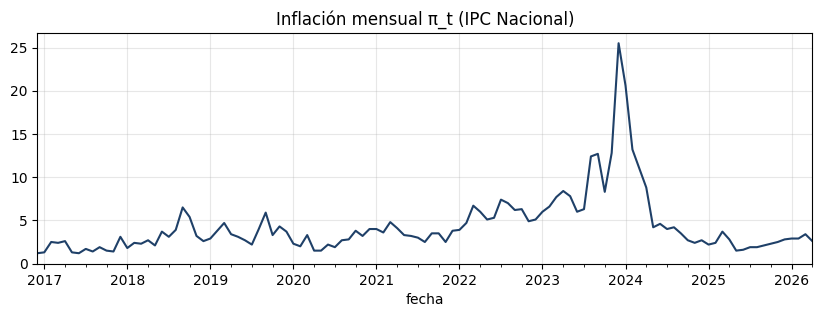

In [4]:
pi = panel["ipc"].rename("pi")
print(desc.summary_stats(pi).to_string(index=False))
desc.plot_series(pi, title="Inflación mensual π_t (IPC Nacional)")
plt.show()

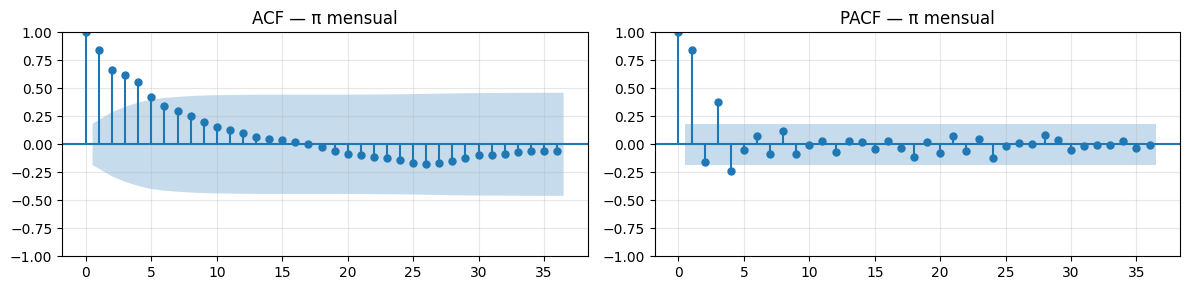

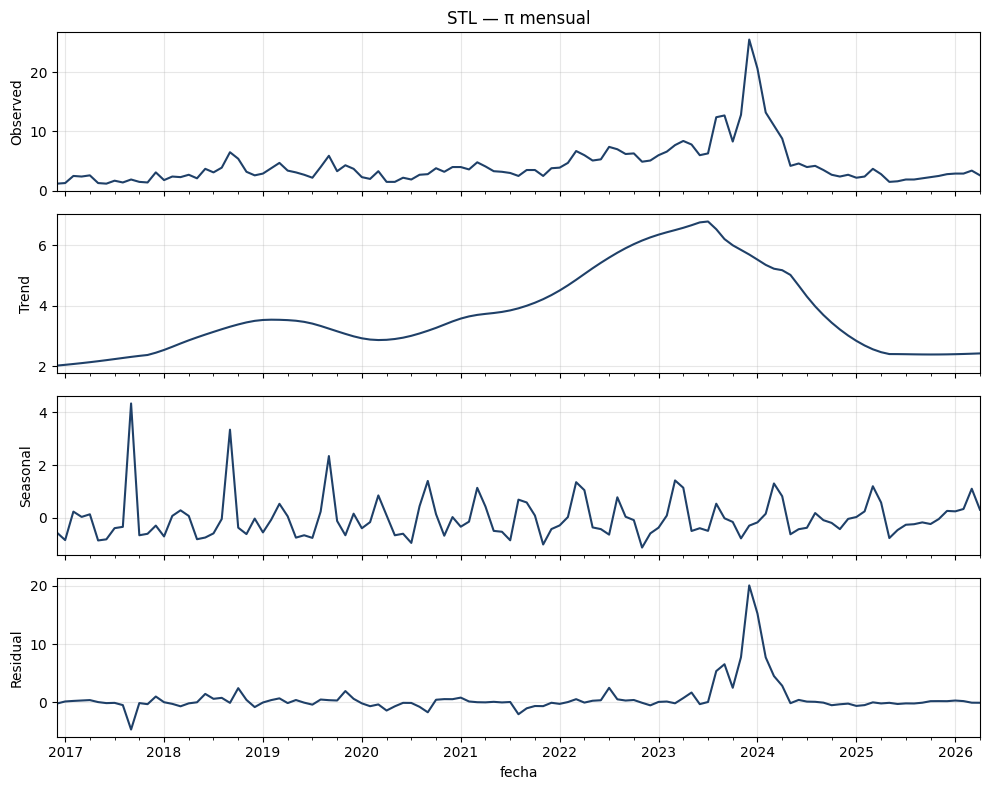

In [5]:
# ACF/PACF y descomposición estacional (Ljung-Box queda en la tabla de diagnóstico).
desc.plot_acf_pacf(pi, lags=36, title="π mensual"); plt.show()
desc.plot_decomposition(pi, period=12, title="π mensual"); plt.show()

### 1.1 Tabla resumen de diagnósticos

In [6]:
# Diagnósticos consolidados: estacionariedad + ARCH + normalidad.
diag_pi = pd.concat([
    diag.unit_root_battery(pi)[["test", "regression", "stat", "pvalue", "conclusion"]],
    diag.heteroscedasticity(pi)[["test", "stat", "pvalue", "conclusion"]].assign(regression=""),
    diag.normality(pi)[["test", "stat", "pvalue", "conclusion"]].assign(regression=""),
], ignore_index=True)
print(diag_pi.round(4).to_string(index=False))

# Ljung-Box citado puntualmente: la ACF ya muestra el patrón.
lb = diag.serial_correlation(pi, lags=(12, 24))
print(f"\nLjung-Box(12): stat={lb.iloc[0]['stat']:.2f}, p={lb.iloc[0]['pvalue']:.4f}")
print(f"Ljung-Box(24): stat={lb.iloc[1]['stat']:.2f}, p={lb.iloc[1]['pvalue']:.4f}")

print("\n=== Quiebres estructurales (PELT) ===")
print(diag.structural_breaks(pi).to_string(index=False))

         test regression      stat  pvalue                                  conclusion
          ADF          c   -2.7028  0.0736         do not reject H0 (unit root) @ 0.05
          ADF         ct   -2.7181  0.2286         do not reject H0 (unit root) @ 0.05
         KPSS          c    0.4209  0.0682        do not reject H0 (stationary) @ 0.05
         KPSS         ct    0.1480  0.0483               reject H0 (stationary) @ 0.05
Zivot-Andrews          c   -4.3293  0.1794 do not reject H0 (unit root w/break) @ 0.05
      ARCH-LM              57.7873  0.0000                  reject H0 (no ARCH) @ 0.05
  Jarque-Bera            1016.3967  0.0000                reject H0 (normality) @ 0.05

Ljung-Box(12): stat=281.90, p=0.0000
Ljung-Box(24): stat=292.73, p=0.0000

=== Quiebres estructurales (PELT) ===
                   test  n_breaks                 break_dates
PELT (Bai-Perron-style)         3 [2021-11, 2023-07, 2024-05]


### 1.2 Backtest rolling-origin univariado

In [7]:
uni_factories = {
    "AutoARIMA": lambda: AutoARIMAModel(season_length=12),
    "AutoETS":   lambda: AutoETSModel(season_length=12),
    "AutoTheta": lambda: AutoThetaModel(season_length=12),
    "Chronos-2": lambda: ChronosModel(device="cpu"),
}
uni_long = compare_models(
    factories=uni_factories,
    y=pi, horizons=HORIZONS, initial_window=INITIAL_WINDOW, verbose=True,
)
uni_wide = to_wide_table(uni_long)
uni_wide.round(3)

[backtest] AutoARIMA
[backtest] AutoETS
[backtest] AutoTheta
[backtest] Chronos-2


crps                         mae                        mase  \
horizon       1      3      6      12     1      3      6      12     1    
model                                                                      
AutoARIMA  1.924  3.472  4.447  5.722  2.375  4.040  4.892  6.315  1.255   
AutoETS    1.591  2.674  3.874  4.716  2.161  3.827  5.265  7.001  1.186   
AutoTheta  1.967  3.192  4.239  5.344  2.338  3.781  4.812  6.108  1.275   
Chronos-2  1.859  2.682  3.286  3.617  1.987  3.297  3.993  4.326  1.109   

                                 rmse                       
horizon       3      6      12     1      3      6      12  
model                                                       
AutoARIMA  2.158  2.702  3.544  3.648  6.169  7.464  8.794  
AutoETS    2.069  2.876  3.888  3.645  5.678  7.973  9.769  
AutoTheta  2.052  2.665  3.457  3.783  5.708  7.642  8.877  
Chronos-2  1.875  2.331  2.546  3.479  5.044  5.742  6.183

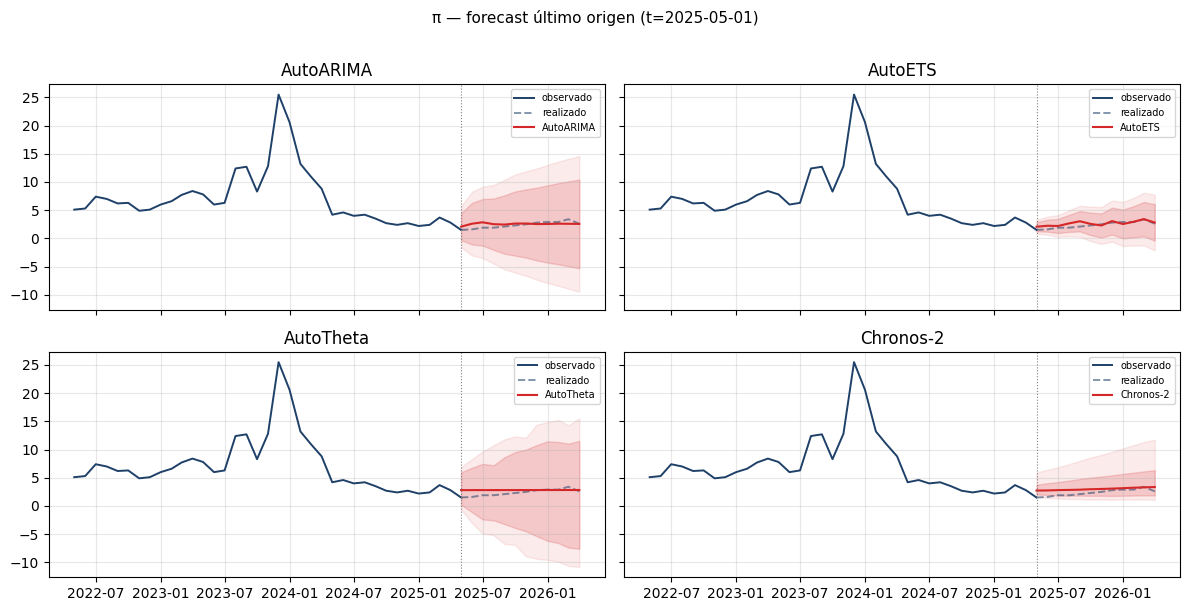

In [8]:
# Forecast en el último origen — un panel por modelo.
uni_forecasts = predict_all_at_last_origin(
    factories=uni_factories,
    y=pi, horizons=HORIZONS, initial_window=INITIAL_WINDOW,
)
origin = uni_forecasts["AutoARIMA"]["origin_idx"]
desc.plot_forecast_grid(
    pi, uni_forecasts, origin_idx=origin, horizon=max(HORIZONS),
    ncols=2,
    title=f"π — forecast último origen (t={pi.index[origin].date()})",
)
plt.show()

## 2 · Validación multivariada (sistema endógeno π, dlog_tcm, m2, d_badlar)

> **Nota sobre lags en multivariado endógeno**: VAR(p), VECM y ChronosMultivariate aprenden internamente la estructura de rezagos del sistema. Pre-shiftear inputs no agrega información — incluso degrada la parametrización. La "decisión de lag" acá es el orden `p` del VAR, seleccionado por AIC/BIC.
>
> El uso de **covariables exógenas con lag óptimo** se aborda en Sec. 3 (SARIMAX / ChronosCov tratan a `X` como regresor exógeno alineado con `y_t`).

Y shape: (112, 4)


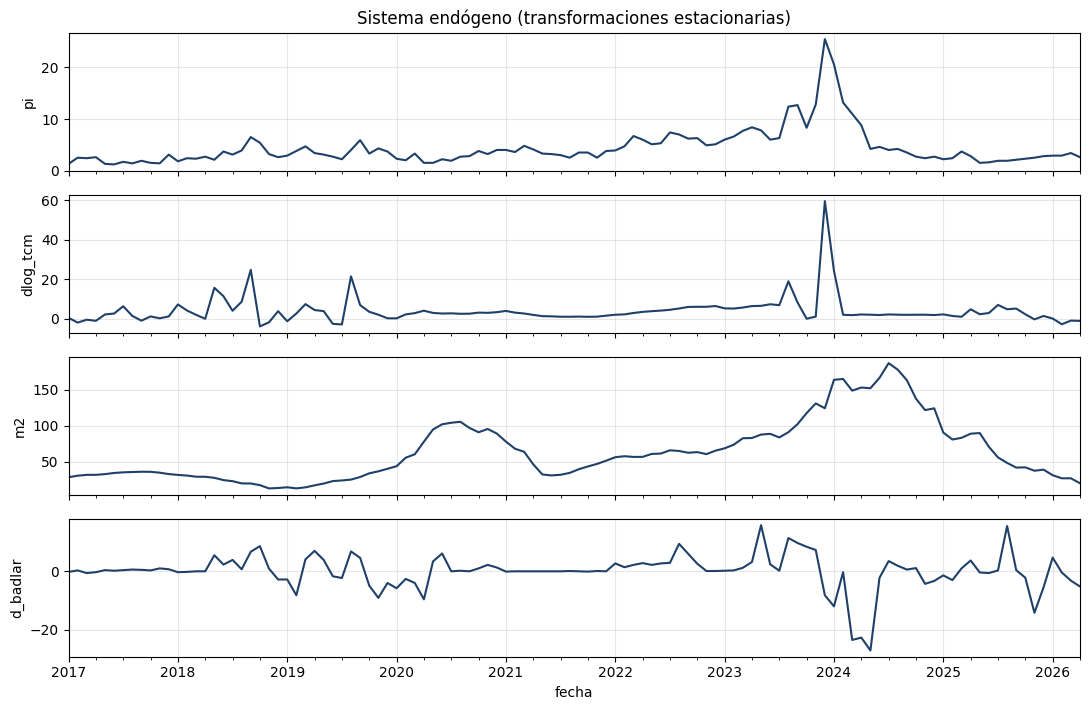

In [9]:
Y = pd.concat({
    "pi":       panel["ipc"],
    "dlog_tcm": log_diff(panel["tcm"], 100),
    "m2":       panel["m2"],
    "d_badlar": panel["badlar"].diff(),
}, axis=1).dropna()
print(f"Y shape: {Y.shape}")
desc.plot_panel(Y, title="Sistema endógeno (transformaciones estacionarias)"); plt.show()

In [10]:
# Selección de orden VAR por AIC/BIC sobre Y (statsmodels).
# Con T~112 obs y k=4 variables, AIC tiende a sobre-parametrizar (VAR(6) implica
# ~100 coeficientes); BIC es el criterio prudente para esta muestra.
from statsmodels.tsa.api import VAR as _SMVAR
order_sel = _SMVAR(Y.to_numpy()).select_order(maxlags=6).selected_orders
p_aic = max(int(order_sel.get("aic", 1)), 1)
p_bic = max(int(order_sel.get("bic", 1)), 1)
p_var = p_bic  # criterio conservador para evitar sobre-parametrización en m2
print(f"Orden VAR sugerido — AIC: {p_aic}, BIC: {p_bic}. Usamos p={p_var} (BIC).")

print("\n=== Granger causality (min p-value sobre lags 1..6) — fila <- columna ===")
print(diag.granger_matrix(Y, maxlag=6).round(3))

# Johansen sobre log-niveles donde aplica.
Yl = pd.DataFrame({
    "log_tcm": np.log(panel["tcm"]),
    "badlar":  panel["badlar"],
    "log_m2":  np.log(panel["m2"]),
}).dropna()
print("\n=== Johansen sobre [log_tcm, badlar, log_m2] ===")
print(diag.johansen_test(Yl).round(3).to_string(index=False))

Orden VAR sugerido — AIC: 6, BIC: 1. Usamos p=1 (BIC).

=== Granger causality (min p-value sobre lags 1..6) — fila <- columna ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1
ssr based chi2 test:   chi2=1.6341  , p=0.2011  , df=1
likelihood ratio test: chi2=1.6222  , p=0.2028  , df=1
parameter F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2
ssr based chi2 test:   chi2=13.6263 , p=0.0011  , df=2
likelihood ratio test: chi2=12.8461 , p=0.0016  , df=2
parameter F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3
ssr based chi2 test:   chi2=3.4353  , p=0.3292  , df=3
likelihood ratio test: chi2=3.3823  , p=0.3364  , df=3
parameter F test:         F=1.0716  ,

**Lectura**: Johansen trace y max-eig rechazan `r ≤ 0` al 95 % pero no `r ≤ 1` → **r = 1**, vector cointegrante entre `log_tcm`, `badlar` y `log_m2`. Se justifica VECM. El orden VAR se fija por BIC (criterio prudente para T~112, k=4); AIC tiende a sobre-parametrizar y degrada el pronóstico de `m2`.

> **VARX como extensión futura**: el wrapper actual de `VARModel` ([mectesis/models/var_model.py](../mectesis/models/var_model.py)) no expone el argumento `exog` de statsmodels. La dimensión de covariables exógenas se aborda con SARIMAX/ChronosCov en Sec. 3.

In [ ]:
multi_factories = {
    f"VAR({p_var})":          (lambda p=p_var: VARModel(lags=p)),
    "VECM(r=1)":               lambda: VECMModel(coint_rank=1, k_ar_diff=1),
    "ChronosMultivariate":     lambda: ChronosMultivariateModel(chronos_pipeline),
}
multi_long = compare_models(
    factories=multi_factories,
    y=Y, horizons=HORIZONS, initial_window=INITIAL_WINDOW, verbose=True,
)
multi_wide = to_wide_table(multi_long)
multi_wide.round(3)


[backtest] VAR(1)
[backtest] VECM(r=1)
[backtest] ChronosMultivariate


crps                             mae          \
horizon                          1       3       6       12      1       3    
variable model                                                                
d_badlar ChronosMultivariate  5.336   5.877   5.986   5.742   6.147   6.726   
         VAR(1)               5.118   6.413   6.819   7.796   6.155   7.604   
         VECM(r=1)            5.006   7.592   8.822   8.617   6.583   9.114   
dlog_tcm ChronosMultivariate  4.255   4.612   5.126   5.283   4.320   5.175   
         VAR(1)               4.828   6.561   7.609   9.793   5.458   7.880   
         VECM(r=1)            6.248   5.084   5.378   5.310   6.395   7.145   
m2       ChronosMultivariate  9.008  17.673  27.169  41.882  10.897  24.724   
         VAR(1)               8.247  20.460  35.699  90.360  10.835  25.540   
         VECM(r=1)            8.137  20.094  33.700  65.823  11.136  23.490   
pi       ChronosMultivariate  1.993   2.802   3.385   3.645   2.229   3.449   
         VAR(1)               2.059   4.083   6.073   8.929   2.555   4.984   
         VECM(r=1)            1.785   2.788   3.939   4.864   2.371   3.838   

                                                mase                       \
horizon                           6        12     1      3      6      12   
variable model                                                              
d_badlar ChronosMultivariate   6.277    6.407  1.403  1.583  1.496  1.473   
         VAR(1)                7.869    9.574  1.408  1.781  1.886  2.216   
         VECM(r=1)            11.365   11.265  1.491  2.056  2.597  2.552   
dlog_tcm ChronosMultivariate   5.722    5.614  0.873  1.051  1.166  1.130   
         VAR(1)                9.064   11.401  1.093  1.562  1.793  2.169   
         VECM(r=1)             7.052    6.255  1.262  1.420  1.425  1.257   
m2       ChronosMultivariate  33.226   58.562  0.334  0.751  1.031  1.842   
         VAR(1)               44.052  104.296  0.332  0.786  1.362  3.247   
         VECM(r=1)            36.654   71.172  0.342  0.711  1.121  2.192   
pi       ChronosMultivariate   4.144    4.333  1.242  1.950  2.394  2.505   
         VAR(1)                7.280   10.349  1.369  2.662  3.907  5.438   
         VECM(r=1)             4.761    5.898  1.282  2.060  2.628  3.306   

                                rmse                           
horizon                           1       3       6        12  
variable model                                                 
d_badlar ChronosMultivariate   9.189  10.170  10.424   10.134  
         VAR(1)                9.525  12.002  12.456   14.419  
         VECM(r=1)             9.787  12.510  14.901   14.867  
dlog_tcm ChronosMultivariate  11.244  11.139  11.144   11.416  
         VAR(1)               11.873  13.977  16.424   24.520  
         VECM(r=1)            13.001  12.290  11.965   11.917  
m2       ChronosMultivariate  14.606  29.208  42.733   65.945  
         VAR(1)               13.150  31.485  54.063  135.658  
         VECM(r=1)            15.549  29.050  46.581   79.687  
pi       ChronosMultivariate   3.802   5.184   5.866    6.142  
         VAR(1)                3.910   7.307  11.386   20.225  
         VECM(r=1)             3.772   5.435   7.212    8.292

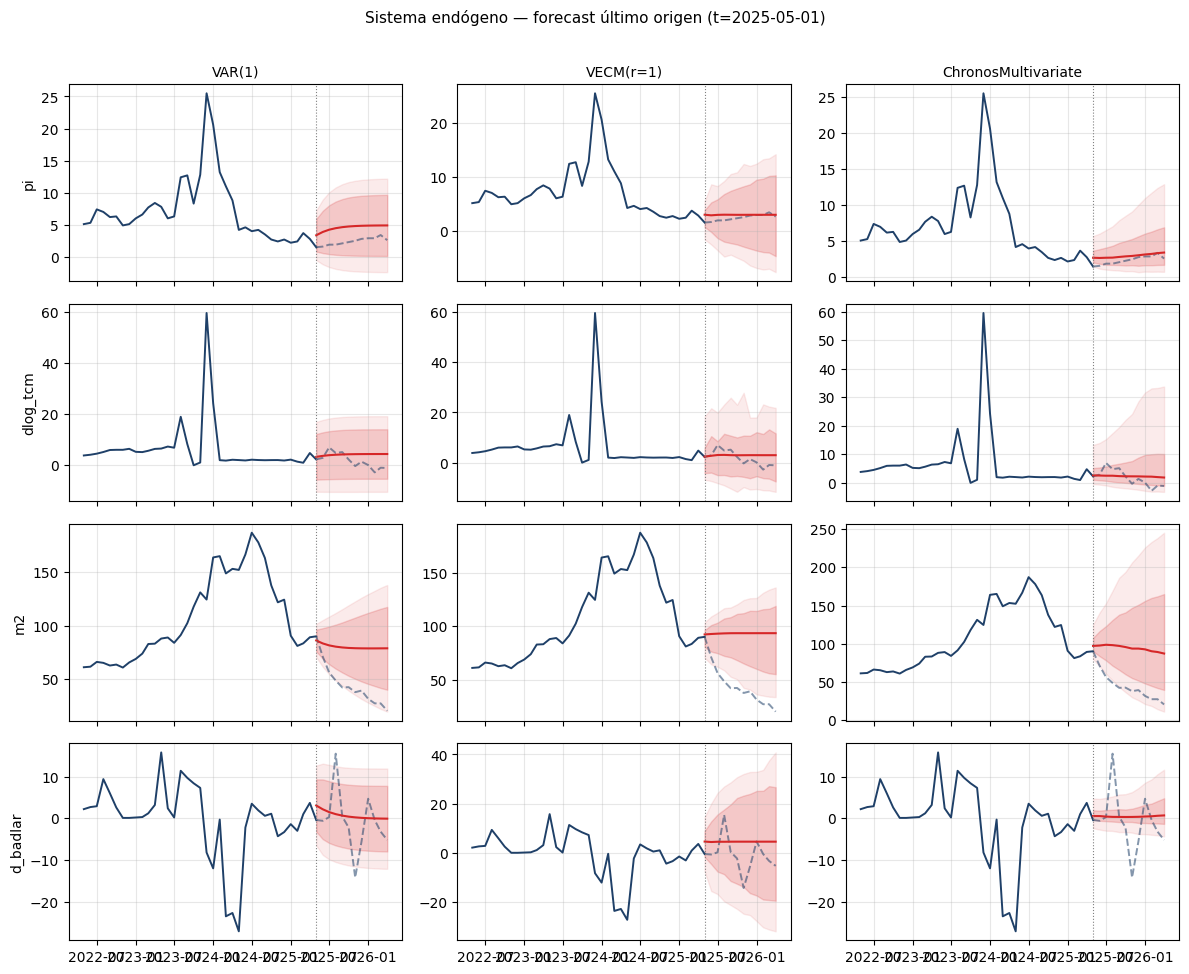

In [12]:
# Matriz modelo × variable en el último origen.
multi_forecasts = predict_all_at_last_origin(
    factories=multi_factories,
    y=Y, horizons=HORIZONS, initial_window=INITIAL_WINDOW,
)
origin = multi_forecasts[next(iter(multi_factories))]["origin_idx"]
desc.plot_forecast_matrix(
    Y, multi_forecasts, origin_idx=origin, horizon=max(HORIZONS),
    title=f"Sistema endógeno — forecast último origen (t={Y.index[origin].date()})",
)
plt.show()

## 3 · Con covariables exógenas + lags óptimos (π ~ X_lagged)

`X = {dlog_tcm, rem, badlar}`. A diferencia de Sec. 2, acá SARIMAX y ChronosCov tratan a `X` como **regresores exógenos** alineados con `y_t`: el punto de entrada temporal lo elegimos nosotros. Aplicamos un **lag óptimo por variable** vía `select_optimal_lags`:

1. Para cada covariable, `cross_corr(π, x)` restringida a `lag ≥ 1` (estrictamente predictiva, evita endogeneidad inversa).
2. `argmax(|corr|)` define el lag candidato.
3. Validación con `granger_matrix`: se descartan covariables con `pval(x → π) > 0.10`.
4. `apply_lags` arma `X_lagged` y los modelos reciben `X_{t-L}` en lugar de `X_t`.

pi: (112,), X_raw: (112, 3)


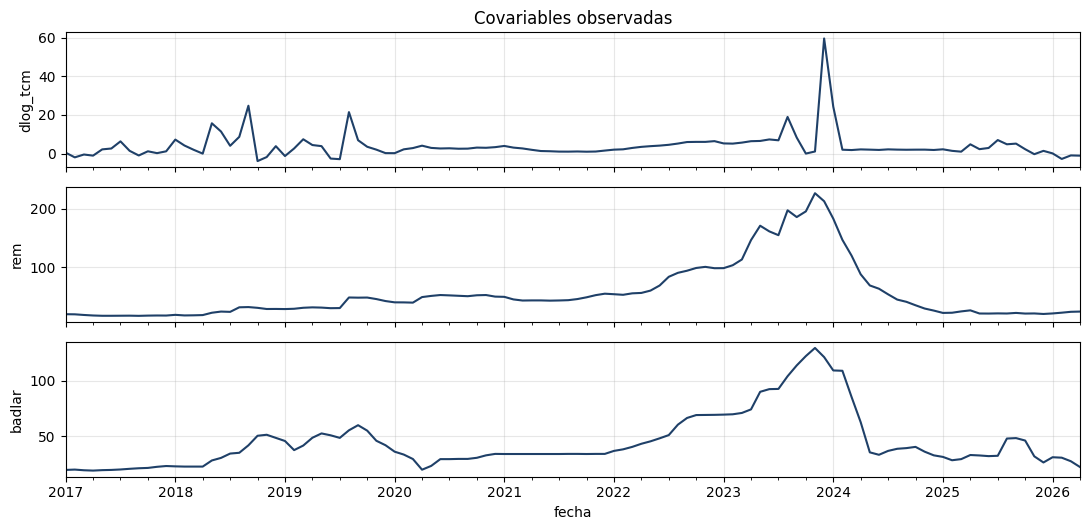

In [13]:
pi_cov = panel["ipc"].rename("pi")
X_raw = pd.concat({
    "dlog_tcm": log_diff(panel["tcm"], 100),
    "rem":      panel["rem"],
    "badlar":   panel["badlar"],
}, axis=1).reindex(pi_cov.index).dropna()
pi_cov = pi_cov.loc[X_raw.index]
print(f"pi: {pi_cov.shape}, X_raw: {X_raw.shape}")
desc.plot_panel(X_raw, title="Covariables observadas"); plt.show()

In [14]:
# Endogeneidad inversa: chequeo bidireccional con Granger antes de elegir lags.
gpanel = pd.concat([pi_cov.rename("pi"), X_raw], axis=1).dropna()
gm = diag.granger_matrix(gpanel, maxlag=6).round(3)
print("=== Granger bidireccional (p-valores, lags 1..6) — fila <- columna ===")
print(gm)

# Cross-correlaciones restringidas a lags predictivos.
print("\n=== Cross-correlaciones predictivas (lag >= 1, max_lag=12) ===")
rows = []
for col in X_raw.columns:
    cc = diag.cross_corr(pi_cov, X_raw[col], max_lag=12)
    cc_pred = cc[cc["lag"] >= 1].reset_index(drop=True)
    best_idx = cc_pred["corr"].abs().idxmax()
    rows.append({
        "variable": col,
        "lag*":     int(cc_pred.loc[best_idx, "lag"]),
        "corr*":    round(float(cc_pred.loc[best_idx, "corr"]), 3),
    })
cc_summary = pd.DataFrame(rows)
print(cc_summary.to_string(index=False))


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1
ssr based chi2 test:   chi2=1.6341  , p=0.2011  , df=1
likelihood ratio test: chi2=1.6222  , p=0.2028  , df=1
parameter F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2
ssr based chi2 test:   chi2=13.6263 , p=0.0011  , df=2
likelihood ratio test: chi2=12.8461 , p=0.0016  , df=2
parameter F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3
ssr based chi2 test:   chi2=3.4353  , p=0.3292  , df=3
likelihood ratio test: chi2=3.3823  , p=0.3364  , df=3
parameter F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.2401  , p=0.2989  

**Diagnóstico complementario — cross-corr con innovaciones de π**

La cross-corr arriba puede confundir señal con autocorrelación: si `π_{t-1}` está fuertemente correlacionada con `π_t` y las covariables también lo están con `π_{t-1}`, aparecen artificialmente como mejores predictoras a lag 1. Una validación es restar primero el efecto autorregresivo: ajustamos un AR(1) a `π`, extraemos los residuos `π_innov_t = π_t - β̂·π_{t-1}` y cruzamos contra `X_{t-lag}`. Si los lags 3-6 emergen acá, son señal genuina más allá de la inercia inflacionaria.

In [15]:
# Cross-corr con innovaciones de un AR(1) sobre pi (control por autocorrelación).
from statsmodels.tsa.ar_model import AutoReg
ar1 = AutoReg(pi_cov, lags=1).fit()
pi_innov = ar1.resid.rename("pi_innov")
print(f"AR(1) sobre π — beta_1 = {ar1.params.iloc[1]:.3f}, R² = {1 - ar1.resid.var()/pi_cov.var():.3f}")

print("\n=== Cross-corr (lag >= 1) — innovaciones AR(1) de π vs covariables ===")
innov_rows = []
for col in X_raw.columns:
    cc = diag.cross_corr(pi_innov, X_raw[col].loc[pi_innov.index], max_lag=12)
    cc_pred = cc[cc["lag"] >= 1].reset_index(drop=True)
    best_idx = cc_pred["corr"].abs().idxmax()
    innov_rows.append({
        "variable":  col,
        "lag*":      int(cc_pred.loc[best_idx, "lag"]),
        "corr*":     round(float(cc_pred.loc[best_idx, "corr"]), 3),
    })
print(pd.DataFrame(innov_rows).to_string(index=False))

AR(1) sobre π — beta_1 = 0.844, R² = 0.715

=== Cross-corr (lag >= 1) — innovaciones AR(1) de π vs covariables ===
variable  lag*  corr*
dlog_tcm     2 -0.266
     rem     1  0.298
  badlar     1  0.272


In [16]:
# Selección automática + filtrado Granger.
# granger_maxlag=6: el filtro chequea Granger sobre lags 1..6 (independiente del
# lag óptimo elegido por cross-corr). Una covariable con cross-corr máxima en
# lag=1 puede tener evidencia Granger en lag=2-3; queremos conservarla.
lag_map = select_optimal_lags(
    y=pi_cov.rename("pi"),
    X=X_raw,
    max_lag=12, min_lag=1,
    granger_panel=gpanel, alpha=0.10,
    granger_maxlag=6,
)
print(f"lag_map (post Granger filter @ alpha=0.10, granger_maxlag=6): {lag_map}")

X_lagged = apply_lags(X_raw, lag_map).dropna()
pi_lag = pi_cov.loc[X_lagged.index]
print(f"\nX_lagged: {X_lagged.shape}, pi_lag: {pi_lag.shape}")
print(f"Obs perdidas por lageo: {X_raw.shape[0] - X_lagged.shape[0]}")
print(X_lagged.head())


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1
ssr based chi2 test:   chi2=1.6341  , p=0.2011  , df=1
likelihood ratio test: chi2=1.6222  , p=0.2028  , df=1
parameter F test:         F=1.5899  , p=0.2101  , df_denom=108, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2
ssr based chi2 test:   chi2=13.6263 , p=0.0011  , df=2
likelihood ratio test: chi2=12.8461 , p=0.0016  , df=2
parameter F test:         F=6.5035  , p=0.0022  , df_denom=105, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3
ssr based chi2 test:   chi2=3.4353  , p=0.3292  , df=3
likelihood ratio test: chi2=3.3823  , p=0.3364  , df=3
parameter F test:         F=1.0716  , p=0.3646  , df_denom=102, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.2401  , p=0.2989  

### 3.1 Backtest con `X_lagged`

In [17]:
cov_factories = {
    "AutoSARIMAX": lambda: AutoSARIMAXModel(season_length=12),
    "ChronosCov":  lambda: ChronosCovariateModel(
        chronos_pipeline,
        n_covariates=X_lagged.shape[1],
        cov_names=list(X_lagged.columns),
    ),
}
cov_long = compare_models(
    factories=cov_factories,
    y=pi_lag, X=X_lagged, horizons=HORIZONS, initial_window=INITIAL_WINDOW, verbose=True,
)
cov_wide = to_wide_table(cov_long)
cov_wide.round(3)

[backtest] AutoSARIMAX
[backtest] ChronosCov


crps                         mae                        mase  \
horizon         1      3      6      12     1      3      6      12     1    
model                                                                        
AutoSARIMAX  1.441  1.834  1.872  0.822  1.736  2.187  2.214  1.071  0.973   
ChronosCov   1.616  1.979  2.263  1.699  1.788  2.405  2.667  1.898  0.996   

                                   rmse                       
horizon         3      6      12     1      3      6      12  
model                                                         
AutoSARIMAX  1.264  1.346  0.590  3.000  3.551  4.194  1.534  
ChronosCov   1.400  1.619  1.118  3.184  4.147  4.801  3.164

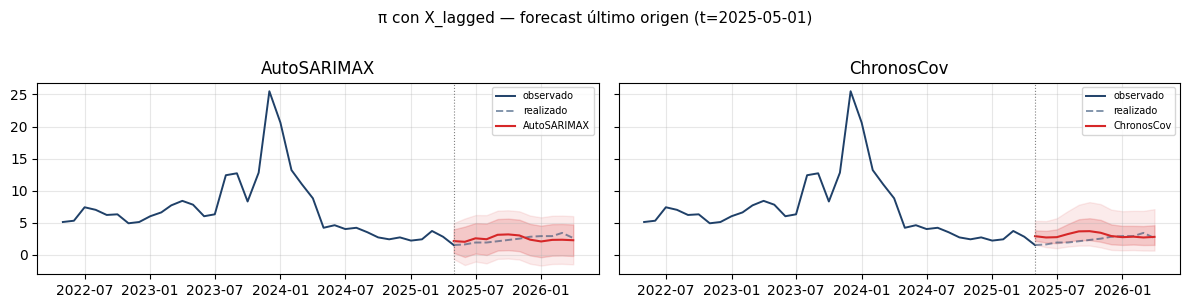

In [18]:
cov_forecasts = predict_all_at_last_origin(
    factories=cov_factories,
    y=pi_lag, X=X_lagged, horizons=HORIZONS, initial_window=INITIAL_WINDOW,
)
origin = cov_forecasts["AutoSARIMAX"]["origin_idx"]
desc.plot_forecast_grid(
    pi_lag, cov_forecasts, origin_idx=origin, horizon=max(HORIZONS),
    ncols=2,
    title=f"π con X_lagged — forecast último origen (t={pi_lag.index[origin].date()})",
)
plt.show()

## 4 · Síntesis

Tabla maestra (modelo × sección × horizonte) y export a `results/empirical/tabla_v2_long.csv`.

In [19]:
uni = uni_long.assign(seccion="univariada")
mul = multi_long.assign(seccion="multivariada")
cov = cov_long.assign(seccion="covariadas_lagged")
master_long = pd.concat([uni, mul, cov], ignore_index=True)
master_long["lag_map"] = master_long["seccion"].map({
    "univariada":          "",
    "multivariada":        "",
    "covariadas_lagged":   str(lag_map),
})

out_dir = pathlib.Path.cwd().parent / "results" / "empirical"
out_dir.mkdir(parents=True, exist_ok=True)
master_long.to_csv(out_dir / "tabla_v2_long.csv", index=False)

master_wide = {
    "univariada":   to_wide_table(uni),
    "multivariada": to_wide_table(mul),
    "covariadas":   to_wide_table(cov),
}
for sec, df in master_wide.items():
    df.to_csv(out_dir / f"tabla_v2_wide_{sec}.csv")
print(f"Guardado en: {out_dir}")
print(f"lag_map usado en Sec. 3: {lag_map}")
master_wide["covariadas"].round(3)

Guardado en: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\results\empirical
lag_map usado en Sec. 3: {'dlog_tcm': 1, 'rem': 1, 'badlar': 1}


crps                         mae                        mase  \
horizon         1      3      6      12     1      3      6      12     1    
model                                                                        
AutoSARIMAX  1.441  1.834  1.872  0.822  1.736  2.187  2.214  1.071  0.973   
ChronosCov   1.616  1.979  2.263  1.699  1.788  2.405  2.667  1.898  0.996   

                                   rmse                       
horizon         3      6      12     1      3      6      12  
model                                                         
AutoSARIMAX  1.264  1.346  0.590  3.000  3.551  4.194  1.534  
ChronosCov   1.400  1.619  1.118  3.184  4.147  4.801  3.164

## Conclusiones y riesgos

- **Univariado**: ranking esperado igual al notebook base (cambios solo cosméticos).
- **Multivariado**: ChronosMulti > VECM > VAR(p_bic). Orden BIC se usa para evitar sobre-parametrización (con T~112 y k=4, VAR(6) genera ~100 coeficientes y explota en `m2`).
- **Con covariables**: la versión v2 usa lags óptimos por variable con `granger_maxlag=6` (validación independiente del lag elegido por cross-corr). Diagnóstico complementario AR(1)-innovations rotula si los lags más largos son señal genuina o sólo arrastre inflacionario.

### Riesgos

- **Tamaño efectivo**: T = 113 − max(lag); con max_lag ≤ 6, ~107 obs. Ventana inicial 72 es viable pero ajustada.
- **Endogeneidad inversa (π → tcm, π → badlar)**: el Granger bidireccional reportado arriba es el control. Si `pval(π → x)` también es < 0.10, hay retroalimentación y el lag óptimo no garantiza identificación causal — sigue siendo útil como feature predictiva.
- **Múltiples comparaciones**: 3 covariables × 12 lags + Granger ⇒ tratamiento exploratorio. No se aplica Bonferroni.
- **Look-ahead leakage**: `apply_lags` impone `lag ≥ 1` y se ejecuta sobre el panel completo antes del split → no hay fuga.
- **VARX descartado por scope**: extensión natural sería VAR con exógenas lageadas; queda como follow-up si Sec. 3 lo amerita.